# UW-Madison GI Tract Image Segmentation
## Threshold Tuning Notebook

This notebook tunes post-processing thresholds for a trained 2.5D U-Net segmentation model.

The workflow is:

1. Rebuild the validation metadata from the original competition files.
2. Recreate the same validation split used during training.
3. Decode organ masks from RLE annotations.
4. Build the validation dataset and dataloader.
5. Load the trained model checkpoint.
6. Evaluate the default threshold of `0.5`.
7. Search class-specific thresholds for `large_bowel`, `small_bowel`, and `stomach`.
8. Save the selected thresholds and validation comparison results.

The model weights are not updated in this notebook. Threshold tuning only changes how probability maps are converted into binary segmentation masks.

## 0. Optional Package Installation

Install the required segmentation package only if it is not already available in the runtime.

In [1]:
# Install these packages only if they are missing from the runtime.
# !pip install -q segmentation-models-pytorch timm

## 1. Imports and Configuration

Load the required libraries and define the paths, model settings, validation split, and threshold search range.

In [2]:
import os
import re
import glob
import json
import time
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import GroupKFold

try:
    import segmentation_models_pytorch as smp
except ImportError as e:
    raise ImportError(
        "segmentation_models_pytorch is not installed. "
        "Please uncomment and run the installation cell above."
    ) from e

pd.set_option("display.max_columns", 100)

In [3]:
class CFG:
    seed = 42

    # ------------------------------------------------------------------
    # Input paths
    # ------------------------------------------------------------------
    # Original Kaggle competition input directory.
    # This is the standard competition path in Kaggle notebooks.
    competition_data_dir = Path("/kaggle/input/competitions/uw-madison-gi-tract-image-segmentation")

    # Path to the trained checkpoint used for validation inference.
    # Example path:
    # checkpoint_path = Path("/kaggle/input/your-model-dataset/best_effnetb0_unet_c_order_fold0.pth")
    checkpoint_path = Path("/kaggle/input/models/lingxd/best-effnetb0-unet-5-31/pytorch/default/1/best_effnetb0_unet_c_order_fold0.pth")

    # ------------------------------------------------------------------
    # Settings that must match the training notebook
    # ------------------------------------------------------------------
    classes = ["large_bowel", "small_bowel", "stomach"]
    img_size = 384
    slice_stride = 2
    n_folds = 5
    fold = 0

    encoder_name = "efficientnet-b0"
    encoder_weights = None  # No need to download ImageNet weights when loading checkpoint.
    in_channels = 3

    batch_size = 8
    num_workers = 2

    # Enable horizontal flip TTA only when the same setting is used for final inference.
    # Threshold tuning and final inference should use the same TTA strategy.
    use_tta = False

    # Candidate probability thresholds evaluated on the validation split.
    threshold_candidates = np.round(np.arange(0.01, 0.71, 0.02), 2)

    device = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(CFG.seed)

print("=" * 100)
print("Threshold tuning configuration")
print("=" * 100)
print("Competition data dir:", CFG.competition_data_dir)
print("Checkpoint path:", CFG.checkpoint_path)
print("Device:", CFG.device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Fold:", CFG.fold)
print("Image size:", CFG.img_size)
print("Slice stride:", CFG.slice_stride)
print("Encoder:", CFG.encoder_name)
print("Use TTA:", CFG.use_tta)
print("Threshold candidates:", CFG.threshold_candidates)

if not CFG.competition_data_dir.exists():
    raise FileNotFoundError(
        f"Competition data directory not found: {CFG.competition_data_dir}. "
        "Please update CFG.competition_data_dir."
    )

if not CFG.checkpoint_path.exists():
    print("\n[Warning] The checkpoint path does not exist.")
    print("Searching for .pth files under /kaggle/input ...")
    possible_paths = glob.glob("/kaggle/input/**/*.pth", recursive=True)
    print(f"Found {len(possible_paths)} .pth files:")
    for p in possible_paths[:30]:
        print("  ", p)
    raise FileNotFoundError(
        f"Checkpoint not found: {CFG.checkpoint_path}\\n"
        "Please update CFG.checkpoint_path using one of the paths printed above."
    )
else:
    print("Checkpoint file found.")

Threshold tuning configuration
Competition data dir: /kaggle/input/competitions/uw-madison-gi-tract-image-segmentation
Checkpoint path: /kaggle/input/models/lingxd/best-effnetb0-unet-5-31/pytorch/default/1/best_effnetb0_unet_c_order_fold0.pth
Device: cuda
GPU: Tesla T4
Fold: 0
Image size: 384
Slice stride: 2
Encoder: efficientnet-b0
Use TTA: False
Threshold candidates: [0.01 0.03 0.05 0.07 0.09 0.11 0.13 0.15 0.17 0.19 0.21 0.23 0.25 0.27
 0.29 0.31 0.33 0.35 0.37 0.39 0.41 0.43 0.45 0.47 0.49 0.51 0.53 0.55
 0.57 0.59 0.61 0.63 0.65 0.67 0.69]
Checkpoint file found.


## 2. Build the Validation DataFrame

This section reconstructs the training metadata from `train.csv` and the image folder structure. The same `GroupKFold` split is applied so that threshold tuning is performed on the validation fold used during model training.

In [4]:
def parse_image_path(path):
    """
    Parse image metadata from a Kaggle MRI image path.

    Expected structure:
        train/case123/case123_day20/scans/slice_0001_266_266_1.50_1.50.png
    """
    path = Path(path)
    filename = path.stem

    parts = filename.split("_")
    if len(parts) < 6:
        raise ValueError(f"Unexpected filename format: {filename}")

    slice_id = int(parts[1])
    height = int(parts[2])
    width = int(parts[3])
    spacing_x = float(parts[4])
    spacing_y = float(parts[5])

    case_str = path.parents[2].name
    case_day_str = path.parents[1].name

    case_match = re.search(r"case(\d+)", case_str)
    day_match = re.search(r"case(\d+)_day(\d+)", case_day_str)

    if case_match is None or day_match is None:
        raise ValueError(f"Unexpected folder format: {path}")

    case = int(case_match.group(1))
    day = int(day_match.group(2))

    image_id = f"case{case}_day{day}_slice_{slice_id:04d}"

    return {
        "id": image_id,
        "case": case,
        "day": day,
        "slice": slice_id,
        "height": height,
        "width": width,
        "spacing_x": spacing_x,
        "spacing_y": spacing_y,
        "image_path": str(path),
    }


def get_nearest_slice(available_slices, target_slice):
    """
    Return the nearest available slice index.
    """
    available_slices = np.array(available_slices)
    nearest_idx = np.argmin(np.abs(available_slices - target_slice))
    return int(available_slices[nearest_idx])


def build_dataframe():
    """
    Build full dataframe with image paths, RLE annotations, organ flags,
    2.5D neighboring paths, and GroupKFold split.
    """
    start_time = time.time()

    train_csv_path = CFG.competition_data_dir / "train.csv"
    train_img_dir = CFG.competition_data_dir / "train"

    if not train_csv_path.exists():
        raise FileNotFoundError(f"train.csv not found: {train_csv_path}")

    if not train_img_dir.exists():
        raise FileNotFoundError(f"train folder not found: {train_img_dir}")

    print("[1/7] Reading train.csv ...")
    train_raw = pd.read_csv(train_csv_path)
    print("Raw train.csv shape:", train_raw.shape)

    print("[2/7] Pivoting annotations to wide format ...")
    train_anno = train_raw.pivot(
        index="id",
        columns="class",
        values="segmentation"
    ).reset_index()

    for c in CFG.classes:
        if c not in train_anno.columns:
            train_anno[c] = np.nan

    train_anno = train_anno[["id"] + CFG.classes]
    train_anno[CFG.classes] = train_anno[CFG.classes].fillna("")
    print("Wide annotation shape:", train_anno.shape)

    print("[3/7] Scanning image paths ...")
    train_image_paths = sorted(
        glob.glob(str(train_img_dir / "case*" / "case*_day*" / "scans" / "*.png"))
    )
    print("Number of training images:", len(train_image_paths))

    if len(train_image_paths) == 0:
        raise RuntimeError("No training images found. Please check competition data path.")

    print("[4/7] Parsing image metadata ...")
    meta_df = pd.DataFrame([parse_image_path(p) for p in train_image_paths])
    print("Metadata shape:", meta_df.shape)

    print("[5/7] Merging metadata with annotations ...")
    df = meta_df.merge(train_anno, on="id", how="left")
    df[CFG.classes] = df[CFG.classes].fillna("")
    print("Merged dataframe shape:", df.shape)

    print("[6/7] Creating organ flags and 2.5D paths ...")
    for c in CFG.classes:
        df[f"has_{c}"] = df[c].apply(lambda x: 1 if isinstance(x, str) and len(x) > 0 else 0)

    df["has_any"] = df[[f"has_{c}" for c in CFG.classes]].max(axis=1)

    path_dict = {
        (int(row["case"]), int(row["day"]), int(row["slice"])): row["image_path"]
        for _, row in df.iterrows()
    }

    slice_dict = (
        df.groupby(["case", "day"])["slice"]
        .apply(lambda x: sorted(x.astype(int).tolist()))
        .to_dict()
    )

    prev_paths = []
    center_paths = []
    next_paths = []

    prev_slices = []
    center_slices = []
    next_slices = []

    for i, (_, row) in enumerate(df.iterrows()):
        if i % 5000 == 0:
            print(f"  Building 2.5D paths: {i}/{len(df)}")

        case = int(row["case"])
        day = int(row["day"])
        center_slice = int(row["slice"])
        available_slices = slice_dict[(case, day)]

        target_slices = [
            center_slice - CFG.slice_stride,
            center_slice,
            center_slice + CFG.slice_stride,
        ]

        selected_slices = []
        selected_paths = []

        for s in target_slices:
            nearest_s = get_nearest_slice(available_slices, s)
            selected_slices.append(nearest_s)
            selected_paths.append(path_dict[(case, day, nearest_s)])

        prev_paths.append(selected_paths[0])
        center_paths.append(selected_paths[1])
        next_paths.append(selected_paths[2])

        prev_slices.append(selected_slices[0])
        center_slices.append(selected_slices[1])
        next_slices.append(selected_slices[2])

    df["image_path_prev"] = prev_paths
    df["image_path_center"] = center_paths
    df["image_path_next"] = next_paths

    df["slice_prev"] = prev_slices
    df["slice_center"] = center_slices
    df["slice_next"] = next_slices

    print("[7/7] Creating GroupKFold split by case ...")
    df["fold"] = -1
    gkf = GroupKFold(n_splits=CFG.n_folds)

    for fold, (_, valid_idx) in enumerate(gkf.split(df, groups=df["case"])):
        df.loc[valid_idx, "fold"] = fold

    print("Fold counts:")
    print(df["fold"].value_counts().sort_index())

    elapsed = time.time() - start_time
    print(f"Dataframe built in {elapsed:.1f} sec")

    return df


df = build_dataframe()
valid_df = df[df["fold"] == CFG.fold].reset_index(drop=True)

print("\nFull dataframe shape:", df.shape)
print("Validation dataframe shape:", valid_df.shape)
print("\nValidation positive ratios:")
display(valid_df[[f"has_{c}" for c in CFG.classes] + ["has_any"]].mean().to_frame("positive_ratio"))

valid_df.head()

[1/7] Reading train.csv ...
Raw train.csv shape: (115488, 3)
[2/7] Pivoting annotations to wide format ...
Wide annotation shape: (38496, 4)
[3/7] Scanning image paths ...
Number of training images: 38496
[4/7] Parsing image metadata ...
Metadata shape: (38496, 9)
[5/7] Merging metadata with annotations ...
Merged dataframe shape: (38496, 12)
[6/7] Creating organ flags and 2.5D paths ...
  Building 2.5D paths: 0/38496
  Building 2.5D paths: 5000/38496
  Building 2.5D paths: 10000/38496
  Building 2.5D paths: 15000/38496
  Building 2.5D paths: 20000/38496
  Building 2.5D paths: 25000/38496
  Building 2.5D paths: 30000/38496
  Building 2.5D paths: 35000/38496
[7/7] Creating GroupKFold split by case ...
Fold counts:
fold
0    7664
1    7712
2    7728
3    7712
4    7680
Name: count, dtype: int64
Dataframe built in 6.8 sec

Full dataframe shape: (38496, 23)
Validation dataframe shape: (7664, 23)

Validation positive ratios:


,positive_ratio
has_large_bowel,0.356211
has_small_bowel,0.290057
has_stomach,0.222860
has_any,0.435282


,id,case,day,slice,height,width,spacing_x,spacing_y,image_path,large_bowel,small_bowel,stomach,has_large_bowel,has_small_bowel,has_stomach,has_any,image_path_prev,image_path_center,image_path_next,slice_prev,slice_center,slice_next,fold
0,case101_day20_slice_0001,101,20,1,266,266,1.5,1.5,/kaggle/input/competitions/uw-madison-gi-tract...,,,,0,0,0,0,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,1,1,3,0
1,case101_day20_slice_0002,101,20,2,266,266,1.5,1.5,/kaggle/input/competitions/uw-madison-gi-tract...,,,,0,0,0,0,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,1,2,4,0
2,case101_day20_slice_0003,101,20,3,266,266,1.5,1.5,/kaggle/input/competitions/uw-madison-gi-tract...,,,,0,0,0,0,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,1,3,5,0
3,case101_day20_slice_0004,101,20,4,266,266,1.5,1.5,/kaggle/input/competitions/uw-madison-gi-tract...,,,,0,0,0,0,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,2,4,6,0
4,case101_day20_slice_0005,101,20,5,266,266,1.5,1.5,/kaggle/input/competitions/uw-madison-gi-tract...,,,,0,0,0,0,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,/kaggle/input/competitions/uw-madison-gi-tract...,3,5,7,0


## 3. RLE Decoding and Image Reading

The competition masks are stored as run-length encoded strings. This section decodes the RLE masks and defines the image-loading utilities used by the validation dataset.

In [5]:
def rle_to_flat(mask_rle, length):
    """
    Convert an RLE string into a flat binary array.
    """
    mask = np.zeros(length, dtype=np.uint8)

    if mask_rle is None or mask_rle == "" or pd.isna(mask_rle):
        return mask

    s = list(map(int, str(mask_rle).split()))
    starts = np.array(s[0::2]) - 1
    lengths = np.array(s[1::2])
    ends = starts + lengths

    for start, end in zip(starts, ends):
        mask[start:end] = 1

    return mask


def rle_decode(mask_rle, shape):
    """
    Decode an RLE string into a binary mask using C-order reshape.
    """
    height, width = shape
    flat = rle_to_flat(mask_rle, height * width)
    return flat.reshape((height, width), order="C")


def read_image(path):
    """
    Read a grayscale MRI slice and normalize it to 0-1 using percentile clipping.
    """
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)

    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")

    img = img.astype(np.float32)

    p1 = np.percentile(img, 1)
    p99 = np.percentile(img, 99)

    img = np.clip(img, p1, p99)
    img = (img - p1) / (p99 - p1 + 1e-6)

    return img


def read_2_5d_image(row):
    """
    Read [n-2, n, n+2] slices and stack them as a 3-channel image.
    Neighboring slices are resized to the center slice size if needed.
    """
    paths = [
        row["image_path_prev"],
        row["image_path_center"],
        row["image_path_next"],
    ]

    center_img = read_image(row["image_path_center"])
    center_h, center_w = center_img.shape[:2]

    images = []

    for p in paths:
        img = read_image(p)

        if img.shape[:2] != (center_h, center_w):
            img = cv2.resize(
                img,
                (center_w, center_h),
                interpolation=cv2.INTER_LINEAR,
            )

        images.append(img)

    image = np.stack(images, axis=-1)

    return image.astype(np.float32)


def read_mask(row):
    """
    Decode three organ masks using C-order RLE decoding.
    Mask shape is taken from the actual center image shape.
    """
    center_img = cv2.imread(str(row["image_path_center"]), cv2.IMREAD_UNCHANGED)

    if center_img is None:
        raise FileNotFoundError(f"Cannot read center image: {row['image_path_center']}")

    height, width = center_img.shape[:2]

    masks = []

    for c in CFG.classes:
        mask = rle_decode(row[c], shape=(height, width))
        masks.append(mask)

    mask = np.stack(masks, axis=-1)

    return mask.astype(np.float32)


print("RLE decoding mode: C-order")

RLE decoding mode: C-order


## 4. Dataset and Validation DataLoader

Create the 2.5D validation dataset by stacking the previous, center, and next MRI slices as three input channels. Validation images and masks are resized to the model input size without random augmentation.

In [6]:
def get_valid_transforms():
    """
    Validation transform. No random augmentation is used.
    """
    return A.Compose([
        A.Resize(
            CFG.img_size,
            CFG.img_size,
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
        ),
        ToTensorV2(transpose_mask=True),
    ])


class UWGIDataset(Dataset):
    """
    Validation dataset for 2.5D UW-Madison GI tract segmentation.
    """
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = read_2_5d_image(row)
        mask = read_mask(row)

        if image.shape[:2] != mask.shape[:2]:
            raise ValueError(
                f"Image and mask shape mismatch at idx={idx}, id={row['id']}: "
                f"image shape={image.shape}, mask shape={mask.shape}"
            )

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        else:
            image = cv2.resize(
                image,
                (CFG.img_size, CFG.img_size),
                interpolation=cv2.INTER_LINEAR,
            )
            mask = cv2.resize(
                mask,
                (CFG.img_size, CFG.img_size),
                interpolation=cv2.INTER_NEAREST,
            )

            image = torch.from_numpy(image.transpose(2, 0, 1)).float()
            mask = torch.from_numpy(mask.transpose(2, 0, 1)).float()

        return image.float(), mask.float()


valid_dataset = UWGIDataset(valid_df, transform=get_valid_transforms())

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=False,
)

print("Validation dataset length:", len(valid_dataset))
print("Validation dataloader batches:", len(valid_loader))

sample_image, sample_mask = valid_dataset[0]
print("Sample image shape:", sample_image.shape, sample_image.dtype)
print("Sample mask shape:", sample_mask.shape, sample_mask.dtype)

Validation dataset length: 7664
Validation dataloader batches: 958
Sample image shape: torch.Size([3, 384, 384]) torch.float32
Sample mask shape: torch.Size([3, 384, 384]) torch.float32


## 5. Build the Model and Load the Checkpoint

Rebuild the U-Net model with the same architecture used during training, then load the saved checkpoint for validation inference.

In [7]:
def build_model():
    """
    Build the same U-Net architecture used during training.
    """
    model = smp.Unet(
        encoder_name=CFG.encoder_name,
        encoder_weights=CFG.encoder_weights,
        in_channels=CFG.in_channels,
        classes=len(CFG.classes),
        activation=None,
    )
    return model


def load_checkpoint_model(checkpoint_path):
    """
    Load trained model checkpoint.
    """
    print("Building model ...")
    model = build_model()

    print("Loading checkpoint:", checkpoint_path)
    checkpoint = torch.load(checkpoint_path, map_location=CFG.device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
        print("Checkpoint format: dictionary with model_state_dict")
        print("Checkpoint epoch:", checkpoint.get("epoch", "unknown"))
        print("Best Dice:", checkpoint.get("best_dice", "unknown"))
    else:
        state_dict = checkpoint
        print("Checkpoint format: raw state_dict")

    new_state_dict = {}

    for k, v in state_dict.items():
        if k.startswith("module."):
            new_key = k.replace("module.", "", 1)
        else:
            new_key = k
        new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict, strict=True)
    model = model.to(CFG.device)
    model.eval()

    print("Model loaded successfully.")

    return model


model = load_checkpoint_model(CFG.checkpoint_path)

Building model ...
Loading checkpoint: /kaggle/input/models/lingxd/best-effnetb0-unet-5-31/pytorch/default/1/best_effnetb0_unet_c_order_fold0.pth
Checkpoint format: dictionary with model_state_dict
Checkpoint epoch: 16
Best Dice: 0.8832072341556161
Model loaded successfully.


## 6. Ground-truth Visualization

Visualize several validation samples to verify that the decoded masks align with the original MRI slices before running threshold tuning.

Positive validation examples: [799, 7168, 1674]
Raw GT visualization
Index: 799
ID: case113_day12_slice_0080
Image path: /kaggle/input/competitions/uw-madison-gi-tract-image-segmentation/train/case113/case113_day12/scans/slice_0080_360_310_1.50_1.50.png
Image shape: (310, 360)
large_bowel: area=2551
small_bowel: area=1628
stomach: area=0


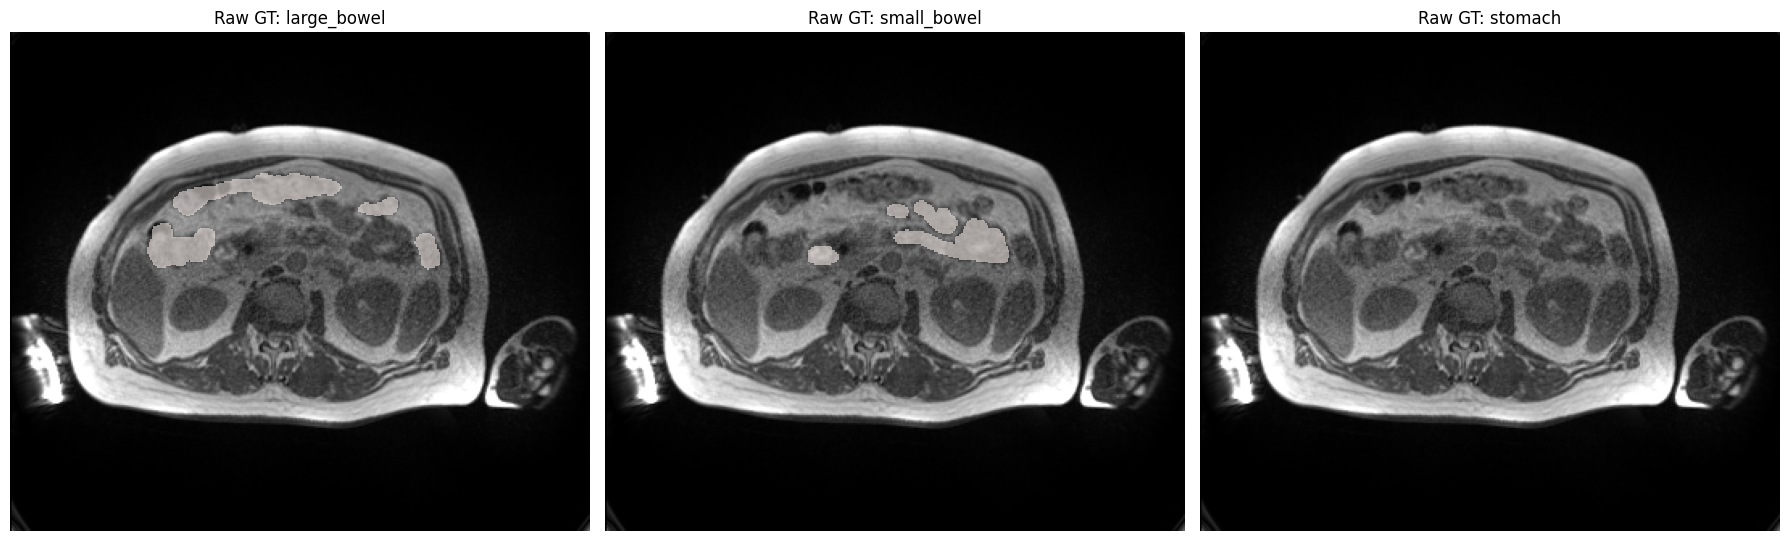

Raw GT visualization
Index: 7168
ID: case9_day22_slice_0081
Image path: /kaggle/input/competitions/uw-madison-gi-tract-image-segmentation/train/case9/case9_day22/scans/slice_0081_360_310_1.50_1.50.png
Image shape: (310, 360)
large_bowel: area=2460
small_bowel: area=683
stomach: area=0


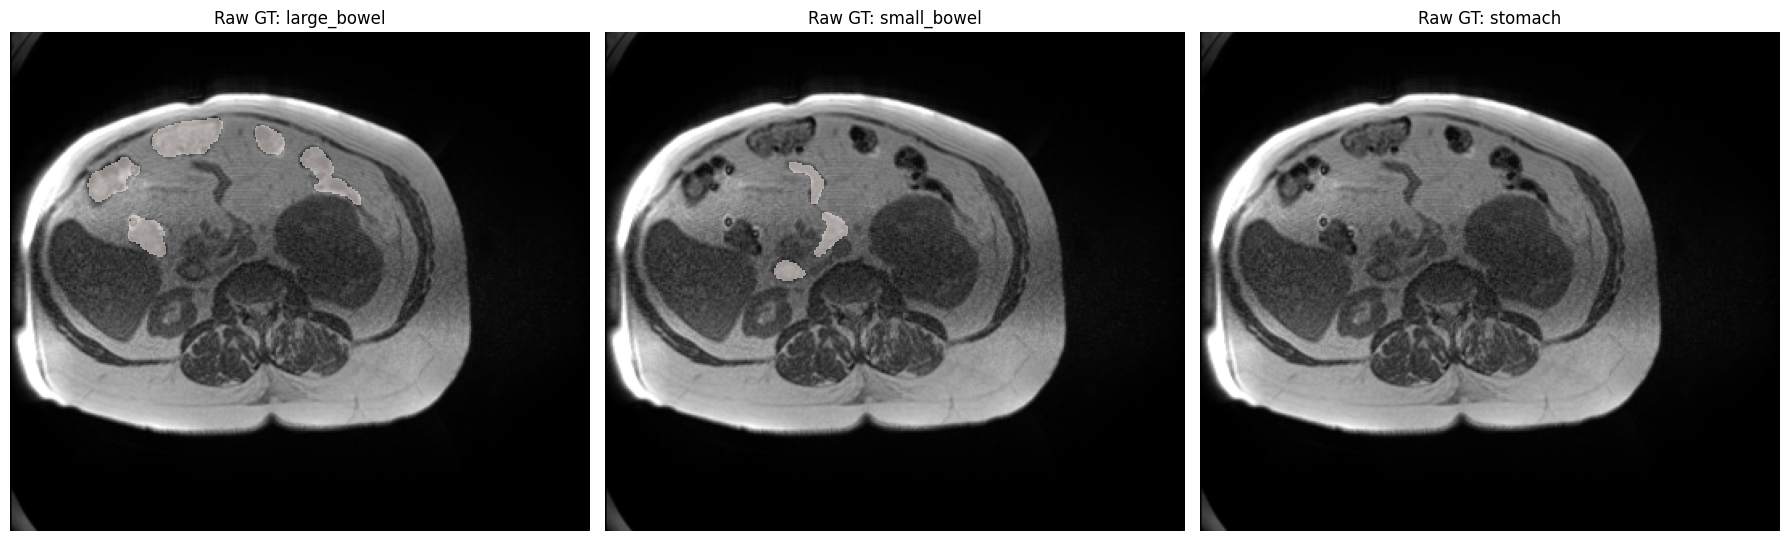

Raw GT visualization
Index: 1674
ID: case114_day17_slice_0091
Image path: /kaggle/input/competitions/uw-madison-gi-tract-image-segmentation/train/case114/case114_day17/scans/slice_0091_360_310_1.50_1.50.png
Image shape: (310, 360)
large_bowel: area=5402
small_bowel: area=1030
stomach: area=0


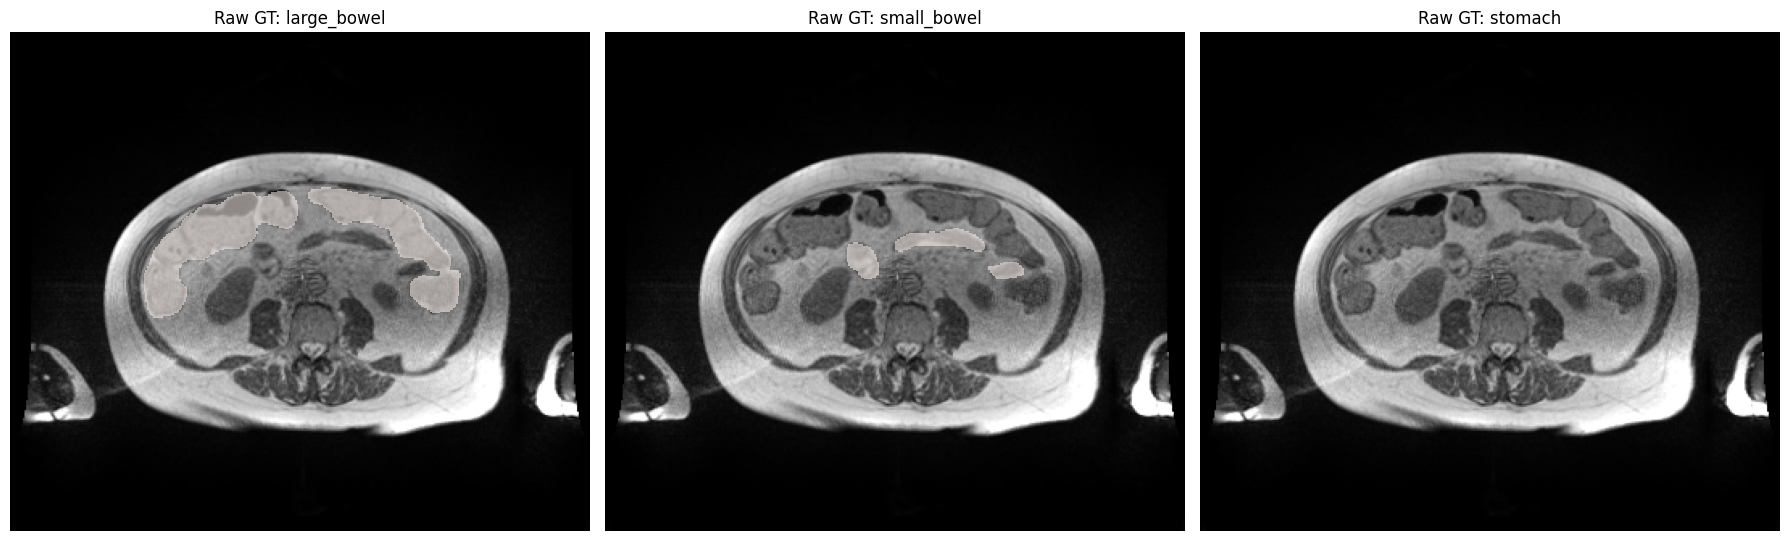

In [8]:
def visualize_raw_ground_truth(row_idx):
    """
    Visualize raw image with C-order decoded masks.
    """
    row = valid_df.iloc[row_idx]

    img = read_image(row["image_path_center"])
    raw_img = cv2.imread(str(row["image_path_center"]), cv2.IMREAD_UNCHANGED)

    h, w = raw_img.shape[:2]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    print("=" * 100)
    print("Raw GT visualization")
    print("Index:", row_idx)
    print("ID:", row["id"])
    print("Image path:", row["image_path_center"])
    print("Image shape:", raw_img.shape)

    for i, c in enumerate(CFG.classes):
        mask = rle_decode(row[c], shape=(h, w))
        print(f"{c}: area={mask.sum()}")

        axes[i].imshow(img, cmap="gray")
        axes[i].imshow(
            np.ma.masked_where(mask == 0, mask),
            cmap="Reds",
            alpha=0.55,
            interpolation="nearest",
        )
        axes[i].set_title(f"Raw GT: {c}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


positive_indices = valid_df[valid_df["has_any"] == 1].sample(
    n=min(3, int(valid_df["has_any"].sum())),
    random_state=CFG.seed,
).index.tolist()

print("Positive validation examples:", positive_indices)

for idx in positive_indices:
    visualize_raw_ground_truth(idx)

## 7. Baseline Dice at Threshold 0.5

Evaluate the trained model on the validation set using the default probability threshold of `0.5`. This baseline is used as the reference for the tuned thresholds.

In [9]:
@torch.no_grad()
def evaluate_training_style_with_class_thresholds(
    model,
    loader,
    thresholds_dict,
    use_tta=False,
):
    """
    Evaluate validation Dice using training-style batch-level Dice.

    This matches the Dice style used in the training notebook more closely:
        - compute Dice per batch
        - if both prediction and target are empty, Dice = 1
        - average batch Dice scores over the validation loader

    Parameters
    ----------
    model : torch.nn.Module
        Trained segmentation model.
    loader : DataLoader
        Validation dataloader.
    thresholds_dict : dict
        Dictionary mapping class name to threshold.
    use_tta : bool
        If True, use horizontal flip TTA during validation inference.

    Returns
    -------
    result : dict
        Mean Dice and per-class Dice.
    """
    model.eval()

    n_classes = len(CFG.classes)

    running_mean_dice = 0.0
    class_dice_sum = torch.zeros(n_classes, device=CFG.device)
    n_batches = 0

    threshold_tensor = torch.tensor(
        [thresholds_dict[c] for c in CFG.classes],
        device=CFG.device,
        dtype=torch.float32,
    ).view(1, n_classes, 1, 1)

    for images, masks in tqdm(loader, desc="Training-style Dice"):
        images = images.to(CFG.device, non_blocking=True)
        masks = masks.to(CFG.device, non_blocking=True).float()

        logits = model(images)
        probs = torch.sigmoid(logits)

        if use_tta:
            images_flip = torch.flip(images, dims=[3])
            logits_flip = model(images_flip)
            probs_flip = torch.sigmoid(logits_flip)
            probs_flip = torch.flip(probs_flip, dims=[3])
            probs = 0.5 * probs + 0.5 * probs_flip

        preds = (probs > threshold_tensor).float()

        dims = (0, 2, 3)

        intersection = torch.sum(preds * masks, dim=dims)
        pred_sum = torch.sum(preds, dim=dims)
        target_sum = torch.sum(masks, dim=dims)

        eps = 1e-7
        class_dice = (2.0 * intersection + eps) / (pred_sum + target_sum + eps)

        # Treat an empty prediction and an empty target as a perfect empty-mask match.
        empty_mask = (pred_sum + target_sum) == 0
        class_dice = torch.where(empty_mask, torch.ones_like(class_dice), class_dice)

        mean_dice = class_dice.mean()

        running_mean_dice += mean_dice.item()
        class_dice_sum += class_dice
        n_batches += 1

    mean_dice = running_mean_dice / max(n_batches, 1)
    class_dice_np = (class_dice_sum / max(n_batches, 1)).detach().cpu().numpy()

    result = {
        "mean_dice": float(mean_dice),
    }

    for i, c in enumerate(CFG.classes):
        result[f"dice_{c}"] = float(class_dice_np[i])

    return result


default_thresholds = {c: 0.5 for c in CFG.classes}

baseline_result = evaluate_training_style_with_class_thresholds(
    model=model,
    loader=valid_loader,
    thresholds_dict=default_thresholds,
    use_tta=CFG.use_tta,
)

print("=" * 100)
print("Baseline training-style validation Dice at threshold 0.5")
print("=" * 100)
print(json.dumps(baseline_result, indent=2))

Training-style Dice:   0%|          | 0/958 [00:00<?, ?it/s]

Baseline training-style validation Dice at threshold 0.5
{
  "mean_dice": 0.8831757063472125,
  "dice_large_bowel": 0.8722650408744812,
  "dice_small_bowel": 0.8446252346038818,
  "dice_stomach": 0.9326367378234863
}


## 8. Class-specific Threshold Search

Evaluate multiple threshold candidates on the validation set. For each candidate threshold, the notebook records the mean Dice score and the Dice score for each organ class.

The threshold search is performed after model inference and does not change the trained checkpoint.

In [10]:
@torch.no_grad()
def tune_thresholds_training_style(
    model,
    loader,
    threshold_candidates,
    use_tta=False,
):
    """
    Tune thresholds using training-style batch-level Dice.

    This function runs model inference once per batch, then evaluates all
    threshold candidates on that batch.

    Metric:
        - compute Dice per batch
        - if both prediction and target are empty, Dice = 1
        - average Dice over validation batches

    This is different from dataset-level foreground Dice, which accumulates
    intersection and area over the whole validation set.
    """
    model.eval()

    thresholds = [float(t) for t in threshold_candidates]
    n_classes = len(CFG.classes)

    class_dice_sums = {
        t: torch.zeros(n_classes, device=CFG.device)
        for t in thresholds
    }

    mean_dice_sums = {
        t: 0.0
        for t in thresholds
    }

    n_batches = 0

    print("=" * 100)
    print("Start training-style threshold tuning")
    print("=" * 100)
    print("Number of validation batches:", len(loader))
    print("Threshold candidates:", thresholds)
    print("Use TTA:", use_tta)

    start_time = time.time()

    for images, masks in tqdm(loader, desc="Training-style threshold tuning"):
        images = images.to(CFG.device, non_blocking=True)
        masks = masks.to(CFG.device, non_blocking=True).float()

        logits = model(images)
        probs = torch.sigmoid(logits)

        if use_tta:
            images_flip = torch.flip(images, dims=[3])
            logits_flip = model(images_flip)
            probs_flip = torch.sigmoid(logits_flip)
            probs_flip = torch.flip(probs_flip, dims=[3])
            probs = 0.5 * probs + 0.5 * probs_flip

        dims = (0, 2, 3)
        eps = 1e-7

        for t in thresholds:
            preds = (probs > t).float()

            intersection = torch.sum(preds * masks, dim=dims)
            pred_sum = torch.sum(preds, dim=dims)
            target_sum = torch.sum(masks, dim=dims)

            class_dice = (2.0 * intersection + eps) / (pred_sum + target_sum + eps)

            empty_mask = (pred_sum + target_sum) == 0
            class_dice = torch.where(empty_mask, torch.ones_like(class_dice), class_dice)

            mean_dice = class_dice.mean()

            class_dice_sums[t] += class_dice
            mean_dice_sums[t] += mean_dice.item()

        n_batches += 1

    records = []

    for t in thresholds:
        class_dice_np = (class_dice_sums[t] / max(n_batches, 1)).detach().cpu().numpy()
        mean_dice = mean_dice_sums[t] / max(n_batches, 1)

        record = {
            "threshold": t,
            "mean_dice": float(mean_dice),
        }

        for i, c in enumerate(CFG.classes):
            record[f"dice_{c}"] = float(class_dice_np[i])

        records.append(record)

    results_df = pd.DataFrame(records)

    elapsed = time.time() - start_time
    print(f"Training-style threshold tuning finished in {elapsed:.1f} sec")

    return results_df


training_style_threshold_results = tune_thresholds_training_style(
    model=model,
    loader=valid_loader,
    threshold_candidates=CFG.threshold_candidates,
    use_tta=CFG.use_tta,
)

display(training_style_threshold_results)

threshold_results_path = Path(f"./threshold_tuning_training_style_c_order_fold{CFG.fold}.csv")
training_style_threshold_results.to_csv(threshold_results_path, index=False)

print("Saved training-style threshold tuning results to:", threshold_results_path)

Start training-style threshold tuning
Number of validation batches: 958
Threshold candidates: [0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19, 0.21, 0.23, 0.25, 0.27, 0.29, 0.31, 0.33, 0.35, 0.37, 0.39, 0.41, 0.43, 0.45, 0.47, 0.49, 0.51, 0.53, 0.55, 0.57, 0.59, 0.61, 0.63, 0.65, 0.67, 0.69]
Use TTA: False


Training-style threshold tuning:   0%|          | 0/958 [00:00<?, ?it/s]

Training-style threshold tuning finished in 135.1 sec


,threshold,mean_dice,dice_large_bowel,dice_small_bowel,dice_stomach
0,0.01,0.865486,0.847929,0.818785,0.929744
1,0.03,0.875262,0.863705,0.831407,0.930675
2,0.05,0.875882,0.863641,0.832394,0.931611
3,0.07,0.877894,0.865670,0.836506,0.931506
4,0.09,0.877818,0.865554,0.836479,0.931422
5,0.11,0.878085,0.866482,0.836395,0.931378
6,0.13,0.878697,0.867422,0.837378,0.931289
7,0.15,0.880019,0.868387,0.840430,0.931239
8,0.17,0.880302,0.868305,0.841414,0.931187
9,0.19,0.880243,0.868223,0.841350,0.931155


Saved training-style threshold tuning results to: threshold_tuning_training_style_c_order_fold0.csv


## 9. Select the Best Thresholds

Select the threshold that gives the highest validation Dice for each organ class. The selected thresholds are saved as a JSON file for later use during inference.

In [11]:
best_thresholds = {}

print("=" * 100)
print("Best training-style threshold per class")
print("=" * 100)

for c in CFG.classes:
    dice_col = f"dice_{c}"
    best_row = training_style_threshold_results.loc[
        training_style_threshold_results[dice_col].idxmax()
    ]

    best_thresholds[c] = float(best_row["threshold"])

    print(
        f"{c}: "
        f"best_threshold={best_row['threshold']:.2f}, "
        f"best_dice={best_row[dice_col]:.6f}"
    )

best_global_row = training_style_threshold_results.loc[
    training_style_threshold_results["mean_dice"].idxmax()
]

print("\nBest single global threshold under training-style Dice:")
print(
    f"threshold={best_global_row['threshold']:.2f}, "
    f"mean_dice={best_global_row['mean_dice']:.6f}"
)

print("\nRecommended class-specific thresholds:")
print(best_thresholds)

thresholds_json_path = Path(f"./best_thresholds_training_style_c_order_fold{CFG.fold}.json")

with open(thresholds_json_path, "w", encoding="utf-8") as f:
    json.dump(best_thresholds, f, indent=2)

print("Saved best training-style thresholds to:", thresholds_json_path)

Best training-style threshold per class
large_bowel: best_threshold=0.39, best_dice=0.872695
small_bowel: best_threshold=0.59, best_dice=0.846455
stomach: best_threshold=0.33, best_dice=0.932994

Best single global threshold under training-style Dice:
threshold=0.59, mean_dice=0.883598

Recommended class-specific thresholds:
{'large_bowel': 0.39, 'small_bowel': 0.59, 'stomach': 0.33}
Saved best training-style thresholds to: best_thresholds_training_style_c_order_fold0.json


## 10. Compare Default and Tuned Thresholds

Re-evaluate the validation set using the selected class-specific thresholds, then compare the results against the default threshold of `0.5`.

In [12]:
tuned_result = evaluate_training_style_with_class_thresholds(
    model=model,
    loader=valid_loader,
    thresholds_dict=best_thresholds,
    use_tta=CFG.use_tta,
)

print("=" * 100)
print("Comparison: default threshold vs training-style tuned thresholds")
print("=" * 100)

comparison_df = pd.DataFrame([
    {
        "setting": "default_0.5",
        **baseline_result,
    },
    {
        "setting": "training_style_class_specific_tuned",
        **tuned_result,
    },
])

display(comparison_df)

comparison_path = Path(f"./threshold_comparison_training_style_c_order_fold{CFG.fold}.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Saved training-style threshold comparison to:", comparison_path)

Training-style Dice:   0%|          | 0/958 [00:00<?, ?it/s]

Comparison: default threshold vs training-style tuned thresholds


,setting,mean_dice,dice_large_bowel,dice_small_bowel,dice_stomach
0,default_0.5,0.883176,0.872265,0.844625,0.932637
1,training_style_class_specific_tuned,0.884048,0.872695,0.846455,0.932994


Saved training-style threshold comparison to: threshold_comparison_training_style_c_order_fold0.csv


## 11. Plot Threshold Tuning Curves

Plot the validation Dice scores across the threshold search range to inspect how sensitive each organ class is to the post-processing threshold.

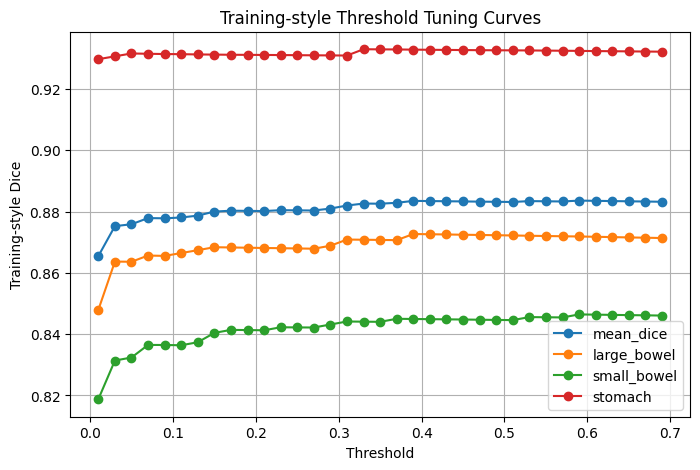

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    training_style_threshold_results["threshold"],
    training_style_threshold_results["mean_dice"],
    marker="o",
    label="mean_dice",
)

for c in CFG.classes:
    plt.plot(
        training_style_threshold_results["threshold"],
        training_style_threshold_results[f"dice_{c}"],
        marker="o",
        label=c,
    )

plt.xlabel("Threshold")
plt.ylabel("Training-style Dice")
plt.title("Training-style Threshold Tuning Curves")
plt.grid(True)
plt.legend()
plt.show()

## 12. Visualize Predictions with Tuned Thresholds

Visualize ground-truth masks, probability maps, and thresholded predictions for positive and empty validation samples.

large_bowel indices: [2639, 7630]
small_bowel indices: [3688, 2083]
stomach indices: [3958, 5570]
empty indices: [6076, 5083]
large_bowel positive samples
Index: 2639
ID: case140_day10_slice_0048
Thresholds: {'large_bowel': 0.39, 'small_bowel': 0.59, 'stomach': 0.33}
large_bowel: GT area=1987, max_prob=1.0000, threshold=0.39, pred_area=2173
small_bowel: GT area=0, max_prob=0.0002, threshold=0.59, pred_area=0
stomach: GT area=5979, max_prob=1.0000, threshold=0.33, pred_area=6027


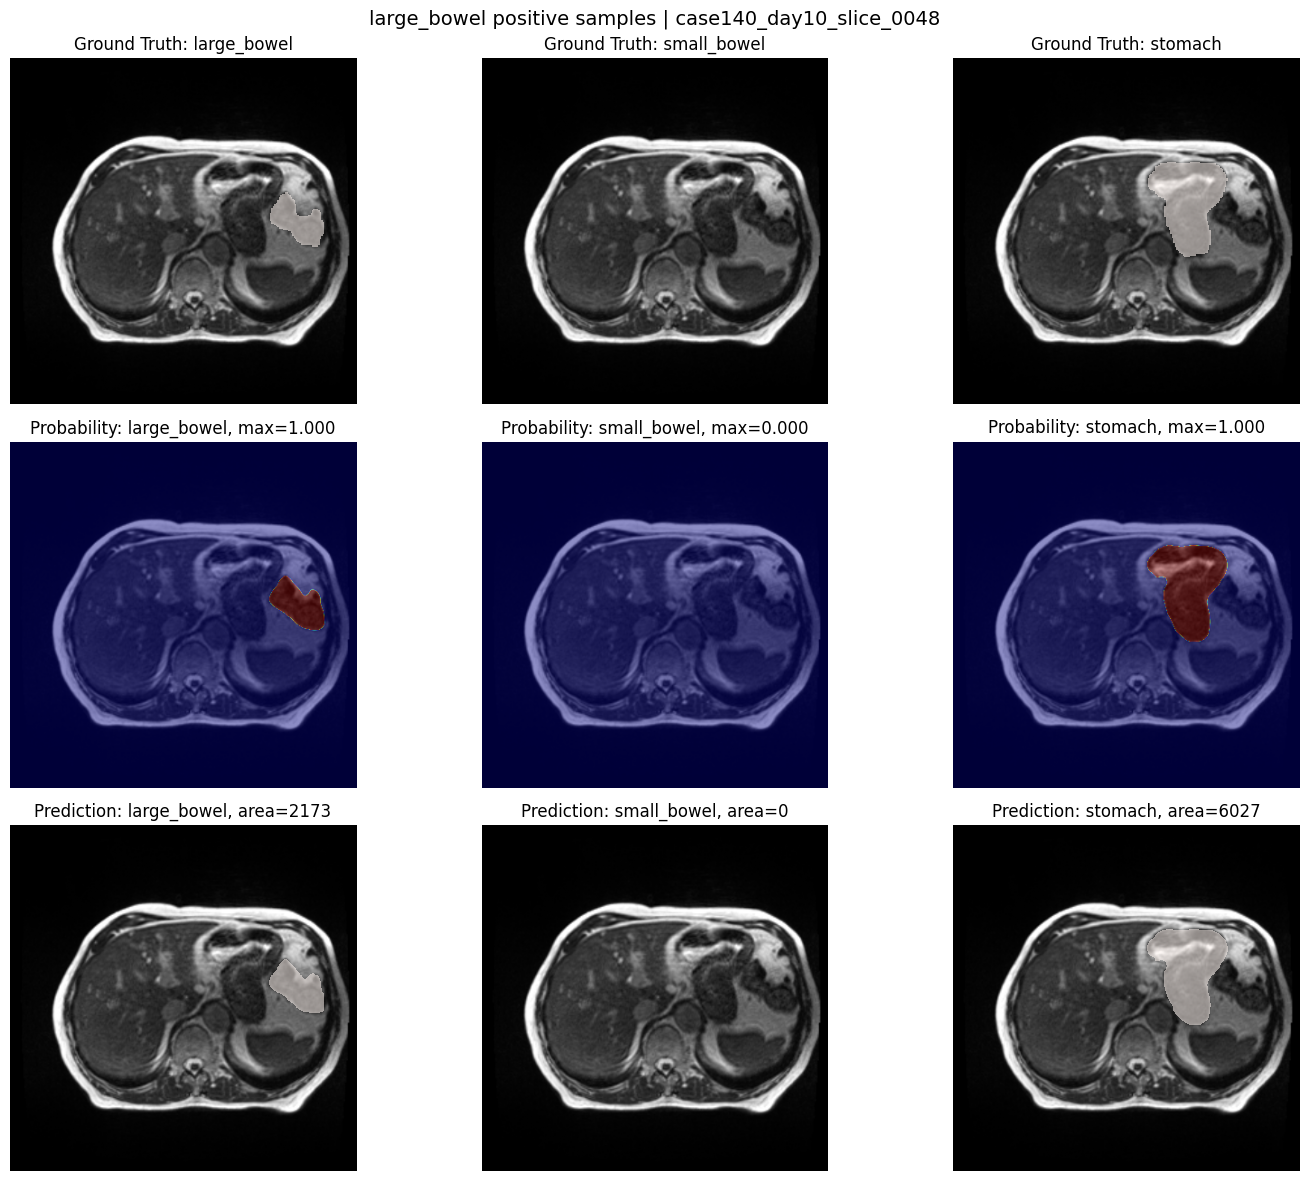

large_bowel positive samples
Index: 7630
ID: case90_day29_slice_0111
Thresholds: {'large_bowel': 0.39, 'small_bowel': 0.59, 'stomach': 0.33}
large_bowel: GT area=4691, max_prob=1.0000, threshold=0.39, pred_area=2788
small_bowel: GT area=2976, max_prob=1.0000, threshold=0.59, pred_area=3536
stomach: GT area=0, max_prob=0.0003, threshold=0.33, pred_area=0


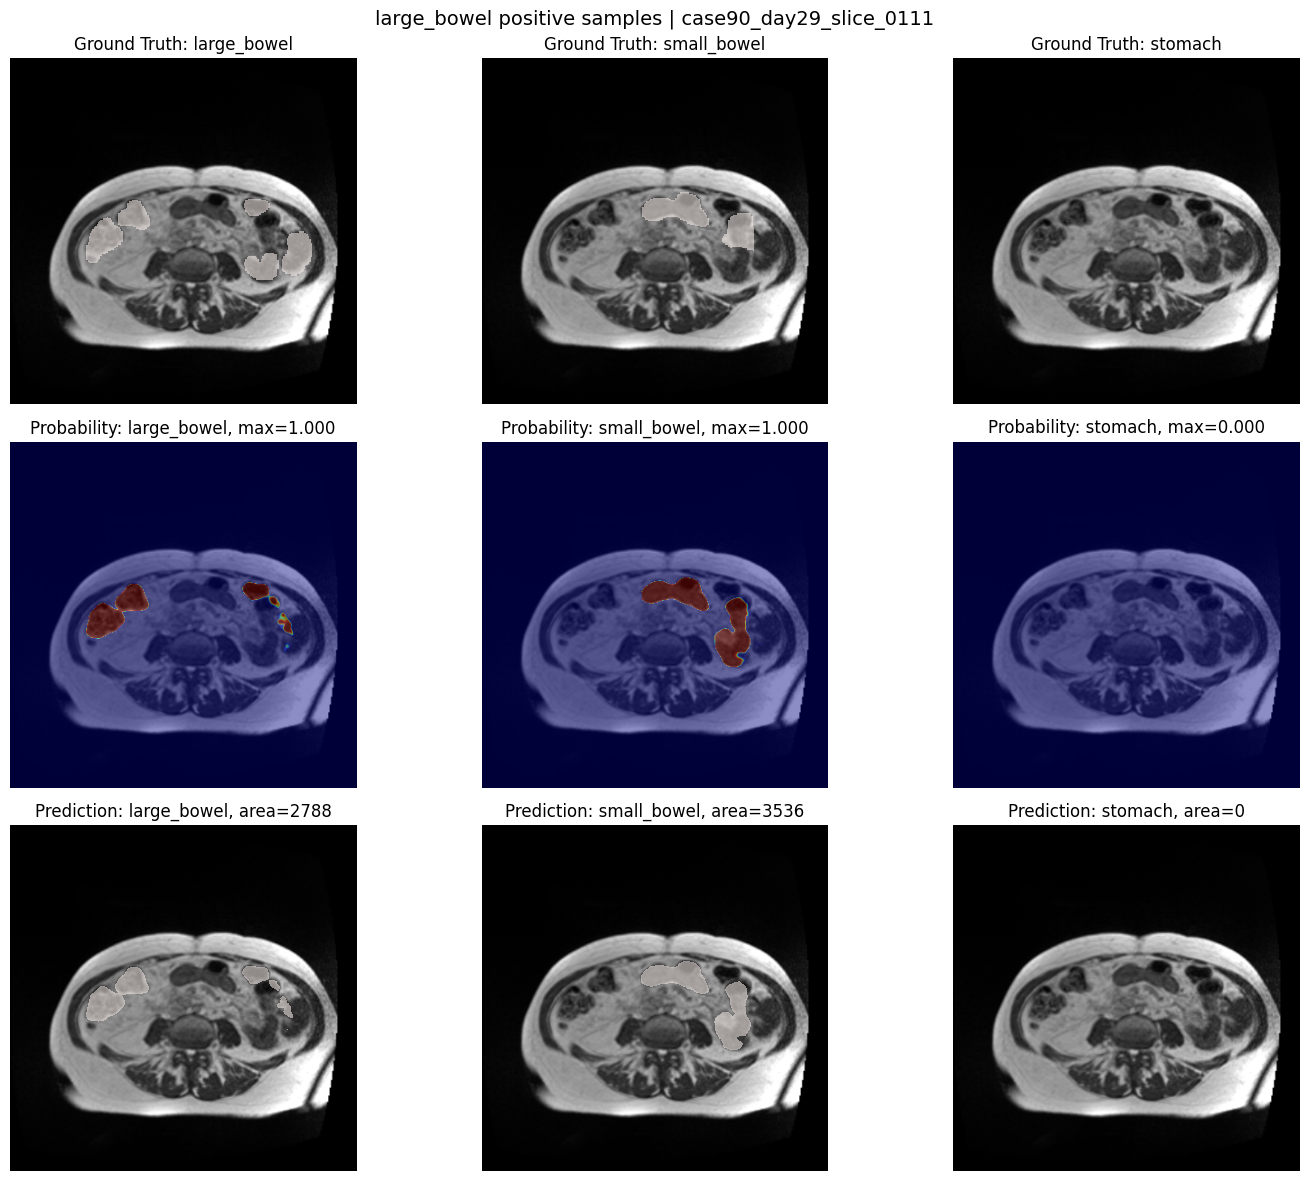

small_bowel positive samples
Index: 3688
ID: case18_day21_slice_0089
Thresholds: {'large_bowel': 0.39, 'small_bowel': 0.59, 'stomach': 0.33}
large_bowel: GT area=1383, max_prob=1.0000, threshold=0.39, pred_area=1708
small_bowel: GT area=4919, max_prob=1.0000, threshold=0.59, pred_area=2496
stomach: GT area=0, max_prob=0.0001, threshold=0.33, pred_area=0


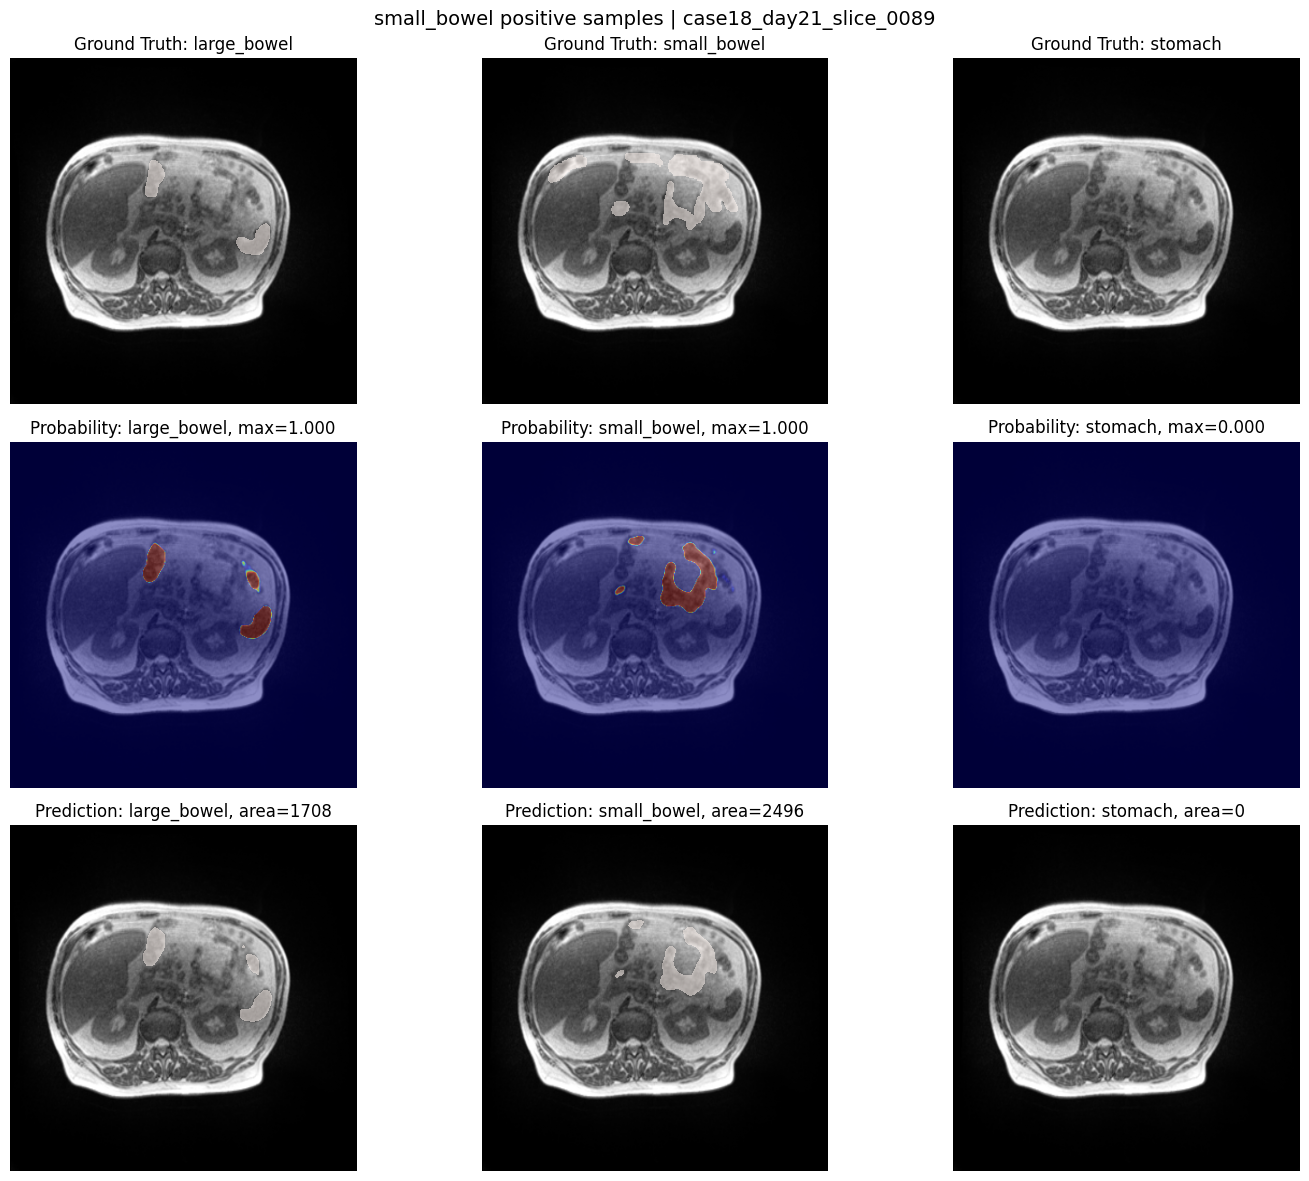

small_bowel positive samples
Index: 2083
ID: case130_day0_slice_0068
Thresholds: {'large_bowel': 0.39, 'small_bowel': 0.59, 'stomach': 0.33}
large_bowel: GT area=1617, max_prob=1.0000, threshold=0.39, pred_area=924
small_bowel: GT area=4142, max_prob=1.0000, threshold=0.59, pred_area=2515
stomach: GT area=2951, max_prob=1.0000, threshold=0.33, pred_area=2284


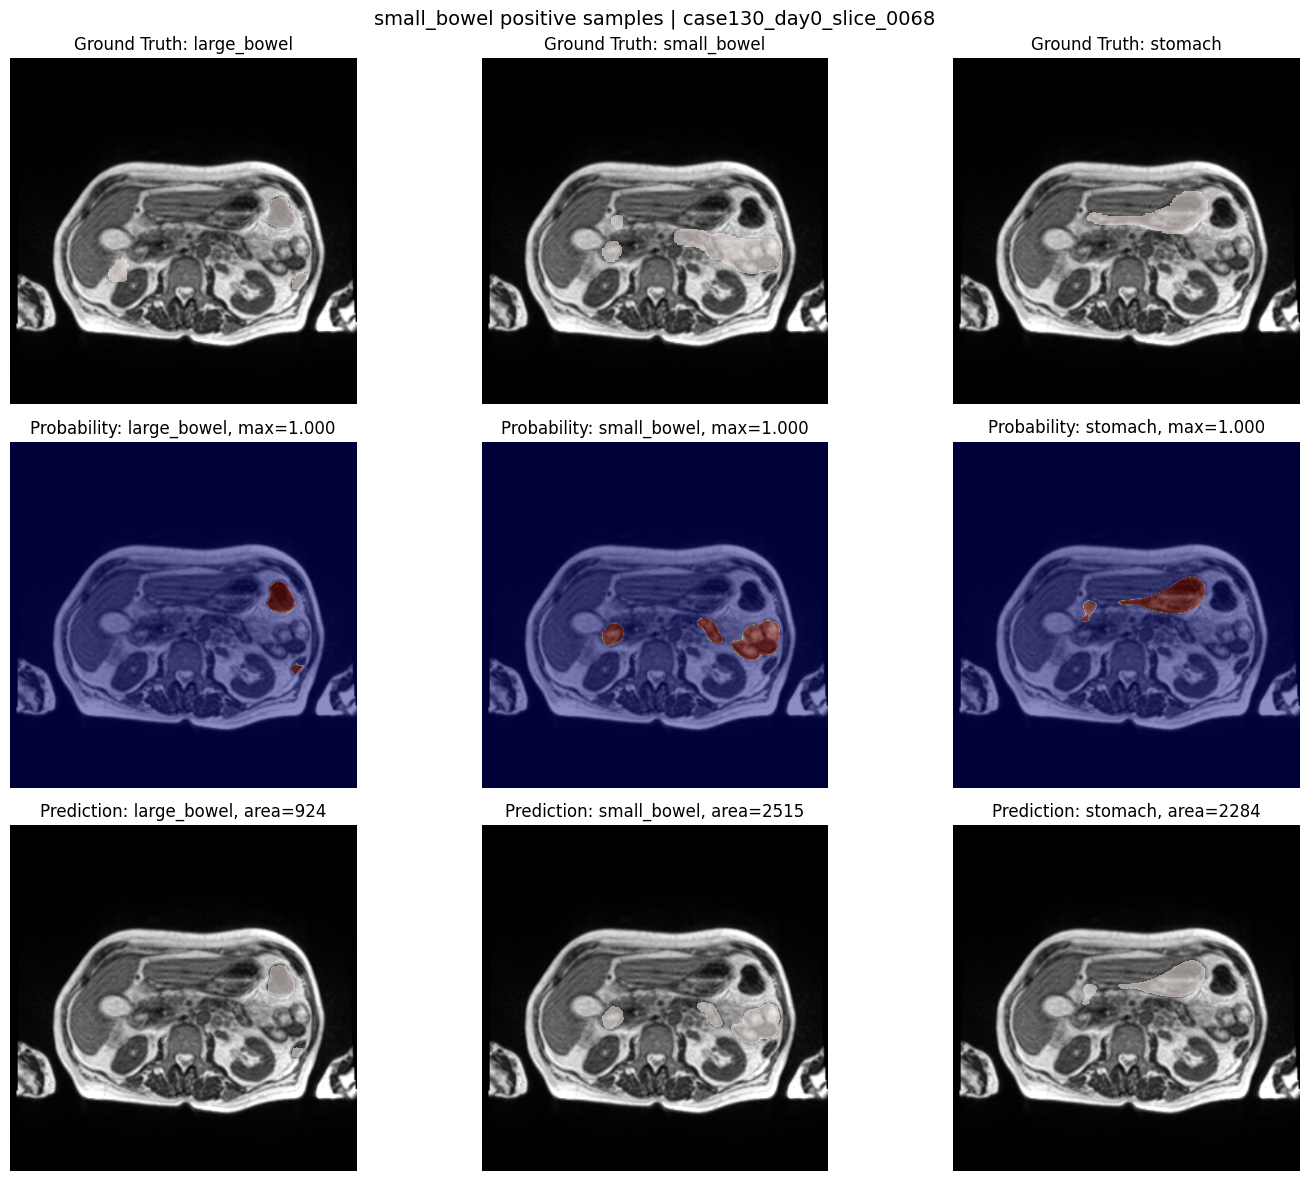

stomach positive samples
Index: 3958
ID: case33_day0_slice_0071
Thresholds: {'large_bowel': 0.39, 'small_bowel': 0.59, 'stomach': 0.33}
large_bowel: GT area=856, max_prob=1.0000, threshold=0.39, pred_area=992
small_bowel: GT area=0, max_prob=0.0223, threshold=0.59, pred_area=0
stomach: GT area=5196, max_prob=1.0000, threshold=0.33, pred_area=4791


In [ ]:
def get_positive_indices(valid_df, organ_name=None, n=3, random_state=42):
    """
    Select validation samples that contain a specific organ.
    """
    if organ_name is None:
        col = "has_any"
    else:
        col = f"has_{organ_name}"

    positive_df = valid_df[valid_df[col] == 1]

    if len(positive_df) == 0:
        return []

    n = min(n, len(positive_df))
    return positive_df.sample(n=n, random_state=random_state).index.tolist()


def get_empty_indices(valid_df, n=3, random_state=42):
    """
    Select validation samples with no organ.
    """
    empty_df = valid_df[valid_df["has_any"] == 0]

    if len(empty_df) == 0:
        return []

    n = min(n, len(empty_df))
    return empty_df.sample(n=n, random_state=random_state).index.tolist()


@torch.no_grad()
def visualize_predictions_with_thresholds(
    model,
    dataset,
    valid_df,
    indices,
    thresholds_dict,
    title_prefix="",
    use_tta=False,
):
    """
    Visualize ground truth, probability maps, and binary predictions.
    """
    if len(indices) == 0:
        print("No indices provided.")
        return

    threshold_array = np.array([thresholds_dict[c] for c in CFG.classes], dtype=np.float32)

    model.eval()

    for idx in indices:
        image, mask = dataset[idx]
        input_tensor = image.unsqueeze(0).to(CFG.device)

        logits = model(input_tensor)
        probs = torch.sigmoid(logits)

        if use_tta:
            input_flip = torch.flip(input_tensor, dims=[3])
            logits_flip = model(input_flip)
            probs_flip = torch.sigmoid(logits_flip)
            probs_flip = torch.flip(probs_flip, dims=[3])
            probs = 0.5 * probs + 0.5 * probs_flip

        prob = probs[0].detach().cpu().numpy()

        pred = np.zeros_like(prob, dtype=np.float32)

        for i, c in enumerate(CFG.classes):
            pred[i] = (prob[i] > thresholds_dict[c]).astype(np.float32)

        image_np = image.detach().cpu().numpy().transpose(1, 2, 0)
        mask_np = mask.detach().cpu().numpy()

        center_img = image_np[:, :, 1]
        row = valid_df.iloc[idx]

        print("=" * 100)
        print(title_prefix)
        print("Index:", idx)
        print("ID:", row["id"])
        print("Thresholds:", thresholds_dict)

        for i, c in enumerate(CFG.classes):
            print(
                f"{c}: "
                f"GT area={mask_np[i].sum():.0f}, "
                f"max_prob={prob[i].max():.4f}, "
                f"threshold={thresholds_dict[c]:.2f}, "
                f"pred_area={pred[i].sum():.0f}"
            )

        fig, axes = plt.subplots(3, 3, figsize=(15, 12))

        for i, c in enumerate(CFG.classes):
            axes[0, i].imshow(center_img, cmap="gray")
            axes[0, i].imshow(
                np.ma.masked_where(mask_np[i] == 0, mask_np[i]),
                cmap="Reds",
                alpha=0.55,
                interpolation="nearest",
            )
            axes[0, i].set_title(f"Ground Truth: {c}")
            axes[0, i].axis("off")

            axes[1, i].imshow(center_img, cmap="gray")
            axes[1, i].imshow(prob[i], cmap="jet", alpha=0.45, vmin=0, vmax=1)
            axes[1, i].set_title(f"Probability: {c}, max={prob[i].max():.3f}")
            axes[1, i].axis("off")

            axes[2, i].imshow(center_img, cmap="gray")
            axes[2, i].imshow(
                np.ma.masked_where(pred[i] == 0, pred[i]),
                cmap="Reds",
                alpha=0.55,
                interpolation="nearest",
            )
            axes[2, i].set_title(f"Prediction: {c}, area={pred[i].sum():.0f}")
            axes[2, i].axis("off")

        plt.suptitle(f"{title_prefix} | {row['id']}", fontsize=14)
        plt.tight_layout()
        plt.show()


large_idx = get_positive_indices(valid_df, organ_name="large_bowel", n=2, random_state=42)
small_idx = get_positive_indices(valid_df, organ_name="small_bowel", n=2, random_state=43)
stomach_idx = get_positive_indices(valid_df, organ_name="stomach", n=2, random_state=44)
empty_idx = get_empty_indices(valid_df, n=2, random_state=45)

print("large_bowel indices:", large_idx)
print("small_bowel indices:", small_idx)
print("stomach indices:", stomach_idx)
print("empty indices:", empty_idx)

visualize_predictions_with_thresholds(
    model,
    valid_dataset,
    valid_df,
    indices=large_idx,
    thresholds_dict=best_thresholds,
    title_prefix="large_bowel positive samples",
    use_tta=CFG.use_tta,
)

visualize_predictions_with_thresholds(
    model,
    valid_dataset,
    valid_df,
    indices=small_idx,
    thresholds_dict=best_thresholds,
    title_prefix="small_bowel positive samples",
    use_tta=CFG.use_tta,
)

visualize_predictions_with_thresholds(
    model,
    valid_dataset,
    valid_df,
    indices=stomach_idx,
    thresholds_dict=best_thresholds,
    title_prefix="stomach positive samples",
    use_tta=CFG.use_tta,
)

visualize_predictions_with_thresholds(
    model,
    valid_dataset,
    valid_df,
    indices=empty_idx,
    thresholds_dict=best_thresholds,
    title_prefix="empty validation samples",
    use_tta=CFG.use_tta,
)

## Output Files

This notebook saves the following files:

```text
threshold_tuning_training_style_c_order_fold0.csv
best_thresholds_training_style_c_order_fold0.json
threshold_comparison_training_style_c_order_fold0.csv
```

The JSON file contains the selected class-specific thresholds. These thresholds can be reused in the inference notebook when converting predicted probability maps into binary masks.